### Part 1
#### 1.2 
Next, fine-tune this model for this task.

In [6]:
# # Lab 3.3 Part 1.2: Fine-tuning BERT for fMRI voxel prediction

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import BertTokenizer, BertModel
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ## Load Raw Text Data
raw_text_path = Path("tmp_ondemand_ocean_mth240012p_symlink/shared/data/raw_text.pkl")
with open(raw_text_path, "rb") as f:
    raw_text = pickle.load(f)

# ## Load fMRI Data
from tqdm import tqdm

def load_subject_data(subject_dir):
    file_list = list(subject_dir.glob("*.npy"))
    print(f" Found {len(file_list)} files in {subject_dir}")
    
    data = {}
    for f in tqdm(file_list, desc=f"Loading {subject_dir.name}"):
        try:
            data[f.stem] = np.load(f)
        except Exception as e:
            print(f" Failed to load {f.name}: {e}")
    return data
    
subject2_dir = Path("tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject2")
subject3_dir = Path("tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject3")

Y_subject2 = load_subject_data(subject2_dir)
Y_subject3 = load_subject_data(subject3_dir)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


/jet/home/xchen26/.conda/envs/env_214/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/tmp/ipykernel_74135/1660089728.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  raw_text = pickle.load(f)


Using device: cuda
 Found 101 files in tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject2


Loading subject2: 100%|██████████| 101/101 [05:23<00:00,  3.21s/it]


 Found 101 files in tmp_ondemand_ocean_mth240012p_symlink/shared/data/subject3


Loading subject3: 100%|██████████| 101/101 [05:33<00:00,  3.30s/it]


In [7]:
print(f"raw_text type: {type(raw_text)}")
sample_key = list(raw_text.keys())[0]
print(f"Sample story ID: {sample_key}")
print(f"raw_text[{sample_key}] type: {type(raw_text[sample_key])}")
print(f"raw_text[{sample_key}].data[:5]: {raw_text[sample_key].data[:5]}")

raw_text type: <class 'dict'>
Sample story ID: sweetaspie
raw_text[sweetaspie] type: <class 'ridge_utils.DataSequence.DataSequence'>
raw_text[sweetaspie].data[:5]: ['', 'i', 'embarked', 'on', 'a']


In [8]:
print(f"Y_subject2 type: {type(Y_subject2)}")
print(f"Y_subject2 keys: {list(Y_subject2.keys())[:3]}")
sid = list(Y_subject2.keys())[0]
print(f"Y_subject2[{sid}].shape: {Y_subject2[sid].shape}")
print(f"Sample voxel vector: {Y_subject2[sid][0][:5]}")

Y_subject2 type: <class 'dict'>
Y_subject2 keys: ['stumblinginthedark', 'singlewomanseekingmanwich', 'theclosetthatateeverything']
Y_subject2[stumblinginthedark].shape: (489, 94251)
Sample voxel vector: [ 0.27800206 -1.4666673   0.17739297  0.62328273  0.30665753]


In [9]:
from itertools import islice

for sid in islice((sid for sid in Y_subject2 if sid in raw_text), 10):
    print(f"{sid} — raw_text: {len(raw_text[sid].data)}  |  Y: {Y_subject2[sid].shape[0]}")

stumblinginthedark — raw_text: 2681  |  Y: 489
singlewomanseekingmanwich — raw_text: 1486  |  Y: 297
theclosetthatateeverything — raw_text: 1928  |  Y: 314
jugglingandjesus — raw_text: 887  |  Y: 193
threemonths — raw_text: 2062  |  Y: 353
escapingfromadirediagnosis — raw_text: 1423  |  Y: 343
wildwomenanddancingqueens — raw_text: 1218  |  Y: 189
igrewupinthewestborobaptistchurch — raw_text: 2449  |  Y: 439
undertheinfluence — raw_text: 1641  |  Y: 304
quietfire — raw_text: 1905  |  Y: 455


In [39]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import BertModel, BertTokenizer
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from preprocessing import downsample_word_vectors, make_delayed
from ridge_utils.ridge import ridge_corr_pred

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DelayedBERTDataset(Dataset):
    def __init__(self, raw_text, fmri_data, delays=range(1, 5), TR=1.0, skip_seconds=(5, 10), window_size=8):
        self.samples = []

        word_vectors = {}
        for sid in raw_text:
            words = raw_text[sid].data
            word_vectors[sid] = np.zeros((len(words), 1), dtype=np.float32)  


        print("Downsampling word sequences to TR resolution...")
        downsampled = downsample_word_vectors(
            stories=list(raw_text.keys()),
            word_vectors=word_vectors,
            wordseqs=raw_text
        )

        trim_start = int(skip_seconds[0] / TR)
        trim_end = int(skip_seconds[1] / TR)
        trimmed = {
            sid: X[trim_start:-trim_end] for sid, X in downsampled.items()
            if X.shape[0] > (trim_start + trim_end)
        }

        print("Creating delayed input features...")
        delayed = {sid: make_delayed(X, delays=delays) for sid, X in trimmed.items()}

        print("Pairing TRs with token windows...")
        for sid in delayed:
            if sid not in fmri_data or sid not in raw_text:
                continue

            Y = fmri_data[sid]
            words = raw_text[sid].data
            T = len(delayed[sid])
            n = min(T, len(Y))
            for i in range(n):
                y = Y[i]
                if np.isnan(y).any():
                    continue
                # Approximate alignment between TR index and word index
                word_idx = int(i * len(words) / len(Y))
                left = max(0, word_idx - window_size)
                right = min(len(words), word_idx + window_size)
                word_window = words[left:right]
                self.samples.append((word_window, y))

        print(f"Total usable samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        word_window, y = self.samples[idx]
        text_input = " ".join(word_window)
        return {
            "input": text_input,
            "target": torch.tensor(y, dtype=torch.float)
        }
        
        
# === Fine-tunable BERT model ===
class BERTVoxelRegressor(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.linear = nn.Linear(self.bert.config.hidden_size, output_dim)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        return self.linear(cls)

# === Training pipeline ===
def train_finetune_bert(raw_text, fmri_data, subject_name):
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    dataset = DelayedBERTDataset(raw_text, fmri_data)
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])
    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)

    output_dim = dataset[0]["target"].shape[0]
    model = BERTVoxelRegressor(output_dim=output_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    criterion = nn.MSELoss()
    best_val_loss = float("inf")
    patience = 3
    pat_counter = 0

    output_dir = f"output/fine_tune/{subject_name}"
    os.makedirs(output_dir, exist_ok=True)
    best_model_path = os.path.join(output_dir, "bert_finetuned.pth")

    for epoch in range(20):
        model.train()
        train_loss = 0
        for batch in train_loader:
            inputs = tokenizer(batch["input"], padding=True, truncation=True,
                               return_tensors="pt", max_length=16).to(device)
            targets = batch["target"].to(device)
            optimizer.zero_grad()
            preds = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                inputs = tokenizer(batch["input"], padding=True, truncation=True,
                                   return_tensors="pt", max_length=16).to(device)
                targets = batch["target"].to(device)
                preds = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
                val_loss += criterion(preds, targets).item()

        print(f"[{subject_name}] Epoch {epoch+1} - Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            pat_counter = 0

        else:
            pat_counter += 1
            if pat_counter >= patience:
                print(" Early stopping")
                break

    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in test_loader:
            inputs = tokenizer(batch["input"], padding=True, truncation=True,
                               return_tensors="pt", max_length=16).to(device)
            targets = batch["target"].cpu().numpy()
            preds = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"]).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(targets)

    pred = np.concatenate(all_preds, axis=0)
    true = np.concatenate(all_targets, axis=0)
    Rstim = pred
    Pstim = pred
    Rresp = true
    Presp = true
    valphas = np.ones(Rresp.shape[1])
    ccs = ridge_corr_pred(Rstim, Pstim, Rresp, Presp, valphas)

    np.save(os.path.join(output_dir, "voxel_cc.npy"), ccs)
    with open(os.path.join(output_dir, "summary_cc.txt"), "w") as f:
        f.write(f"Subject: {subject_name}\\n")
        f.write(f"Mean CC: {np.mean(ccs):.4f}\\n")
        f.write(f"Median CC: {np.median(ccs):.4f}\\n")
        f.write(f"Top 5%: {np.quantile(ccs, 0.95):.4f}\\n")
        f.write(f"Top 1%: {np.quantile(ccs, 0.99):.4f}\\n")

    plt.figure()
    plt.hist(ccs, bins=50, color='skyblue', edgecolor='black')
    plt.title(f"CC Distribution for {subject_name}")
    plt.xlabel("Voxel-wise Correlation (CC)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "cc_distribution.png"), dpi=300)
    plt.close()
    print(f"Final mean CC: {np.mean(ccs):.4f}")
    return ccs

# === Run for both subjects ===
subject_map = {
    "subject2": Y_subject2
    "subject3": Y_subject3
}

all_ccs = {}
for name, ydata in subject_map.items():
    all_ccs[name] = train_finetune_bert(raw_text, ydata, name)

for name, ccs in all_ccs.items():
    print(f"== {name} Summary ==")
    print(f" Mean: {np.mean(ccs):.4f}")
    print(f" Median: {np.median(ccs):.4f}")
    print(f" Top 5% Quantile: {np.quantile(ccs, 0.95):.4f}")
    print(f" Top 1% Quantile: {np.quantile(ccs, 0.99):.4f}")

Downsampling word sequences to TR resolution...
Creating delayed input features...
Pairing TRs with token windows...
Total usable samples: 34786
[subject3] Epoch 1 - Train Loss: 0.9831, Val Loss: 0.9757
[subject3] Epoch 2 - Train Loss: 0.9810, Val Loss: 0.9756
[subject3] Epoch 3 - Train Loss: 0.9810, Val Loss: 0.9756
[subject3] Epoch 4 - Train Loss: 0.9807, Val Loss: 0.9748
[subject3] Epoch 5 - Train Loss: 0.9715, Val Loss: 0.9692
[subject3] Epoch 6 - Train Loss: 0.9538, Val Loss: 0.9657
[subject3] Epoch 7 - Train Loss: 0.9423, Val Loss: 0.9613
[subject3] Epoch 8 - Train Loss: 0.9364, Val Loss: 0.9602
[subject3] Epoch 9 - Train Loss: 0.9329, Val Loss: 0.9587
[subject3] Epoch 10 - Train Loss: 0.9295, Val Loss: 0.9567
[subject3] Epoch 11 - Train Loss: 0.9257, Val Loss: 0.9559
[subject3] Epoch 12 - Train Loss: 0.9225, Val Loss: 0.9538
[subject3] Epoch 13 - Train Loss: 0.9199, Val Loss: 0.9525
[subject3] Epoch 14 - Train Loss: 0.9177, Val Loss: 0.9522
[subject3] Epoch 15 - Train Loss: 0.91

In [16]:
import numpy as np
import joblib
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
import sys
import importlib.util
import os

In [27]:
ridge_py_path = Path("ridge.py")
ridge_utils_dir = Path("ridge_utils") 

sys.path.append(str(ridge_utils_dir))

spec = importlib.util.spec_from_file_location("ridge", ridge_py_path)
ridge = importlib.util.module_from_spec(spec)
sys.modules["ridge"] = ridge
spec.loader.exec_module(ridge)
bootstrap_ridge = ridge.bootstrap_ridge

embedding_path = "Filetune_embeddings.npz"
npz_data = np.load(embedding_path)

selected_stories = ["hangtime", "golfclubbing"]

X_dict = {
    "X_bert": {
        story: npz_data[story] for story in selected_stories if story in npz_data
    }
}

In [73]:
print(npz_data.files) 

['sweetaspie', 'thatthingonmyarm', 'tildeath', 'indianapolis', 'lawsthatchokecreativity', 'golfclubbing', 'jugglingandjesus', 'shoppinginchina', 'cocoonoflove', 'hangtime']


Ridge Regression:

In [52]:
results = []

def zs(v):
    std = v.std(axis=0)
    std[std == 0] = 1
    return (v - v.mean(axis=0)) / std

top_voxel_results = []  

TOP_N = 5 

for x_key, x_data in X_dict.items():
    for subj_key, y_data in [("subj3", Y_subject3)]:
        shared_stories = sorted(list(set(x_data.keys()) & set(y_data.keys())))
        for story in shared_stories:
            print(f"[Running] {x_key} - {subj_key} - {story}")
            X = x_data[story]
            Y = y_data[story]

            if X.shape[0] != Y.shape[0]:
                print(f"  [Skip] Mismatch in shape: X={X.shape}, Y={Y.shape}")
                continue

            X_z = zs(X)
            Y_z = zs(Y)
            X_train, X_test, Y_train, Y_test = train_test_split(X_z, Y_z, test_size=0.2, random_state=42)
            alphas = np.logspace(0, 3, 20)
            wt, corrs, valalphas, _, _ = bootstrap_ridge(
                X_train, Y_train, X_test, Y_test,
                alphas=alphas, nboots=10, chunklen=10, nchunks=2,
                return_wt=True
            )

            results.append({
                "X_type": x_key,
                "subject": subj_key,
                "story": story,
                "mean_cc": float(np.mean(corrs)),
                "corrs": corrs,
                "wt": wt,
                "X": X_test,
                "Y": Y_test
            })

            top_voxel_ids = np.argsort(corrs)[-TOP_N:][::-1]
            for voxel_id in top_voxel_ids:
                top_voxel_results.append({
                    "story": story,
                    "voxel_id": voxel_id,
                    "X": X_test,
                    "wt": wt[:, voxel_id],  
                    "cc": corrs[voxel_id]
                })

            print(f"  [Done] Mean CC={np.mean(corrs):.3f}, Top voxel CCs: {corrs[top_voxel_ids]}")



[Running] X_bert - subj3 - golfclubbing
  [Done] Mean CC=0.367, Top voxel CCs: [0.93772921 0.92572742 0.92262673 0.92238917 0.92212829]
[Running] X_bert - subj3 - hangtime
  [Done] Mean CC=0.242, Top voxel CCs: [0.85015257 0.84890563 0.83732935 0.83499378 0.83078629]


In [48]:
def make_sentences_from_raw(raw_text_seq, window_size=8):
    words = raw_text_seq.data
    sentences = []
    for i in range(window_size, len(words) - window_size):
        window = words[i - window_size:i + window_size]
        sentence = " ".join(window)
        sentences.append(sentence)
    return sentences

Load the Module

In [54]:
class BERTVoxelRegressor(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.linear = nn.Linear(self.bert.config.hidden_size, output_dim)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        return self.linear(cls)
    
output_dim = 95556

model = BERTVoxelRegressor(output_dim=output_dim).to(device)
model.load_state_dict(torch.load("output/fine_tune/subject3/bert_finetuned.pth"))
model.eval()

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

SHAP

In [61]:
def explain_voxel_by_text(story_id, voxel_index, model, tokenizer, raw_text, max_sentences=100, display=True):
    import shap
    import numpy as np
    from collections import defaultdict

    def predict_voxel(text_input):
        if isinstance(text_input, np.ndarray):
            text_input = text_input.tolist()
        if isinstance(text_input, str):
            text_input = [text_input]
        tokens = tokenizer(text_input, return_tensors="pt", padding=True, truncation=True,
                           max_length=16).to(model.bert.device)
        with torch.no_grad():
            preds = model(tokens["input_ids"], tokens["attention_mask"])
        return preds[:, voxel_index].cpu().numpy()

    def make_sentences_from_raw(raw_text_seq, window_size=8):
        words = raw_text_seq.data
        sentences = []
        for i in range(window_size, len(words) - window_size):
            window = words[i - window_size:i + window_size]
            sentence = " ".join(window)
            sentences.append(sentence)
        return sentences

    if story_id not in raw_text:
        raise ValueError(f"Story '{story_id}' not found in raw_text.")
    sentences = make_sentences_from_raw(raw_text[story_id])[:max_sentences]

    explainer = shap.Explainer(predict_voxel, tokenizer)
    shap_values = explainer(sentences)

    word_scores = defaultdict(float)
    for s in shap_values:
        for token, val in zip(s.data, s.values):
            word_scores[token] += abs(val)
    top_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:15]
    
    print(f"\nTop influential words for voxel {voxel_index} in story '{story_id}':")
    for word, score in top_words:
        print(f"{word:<15}  {score:.4f}")

    return shap_values, top_words

def batch_explain_top_voxels(top_voxel_results, model, tokenizer, raw_text, max_sentences=100, display=True):
    all_results = []
    for i, item in enumerate(top_voxel_results):
        story = item["story"]
        voxel_id = item["voxel_id"]
        print(f"\n [{i+1}/{len(top_voxel_results)}] Explaining voxel {voxel_id} from story '{story}'")
        try:
            shap_values, top_words = explain_voxel_by_text(
                story_id=story,
                voxel_index=voxel_id,
                model=model,
                tokenizer=tokenizer,
                raw_text=raw_text,
                max_sentences=max_sentences,
                display=display
            )
            all_results.append({
                "story": story,
                "voxel_id": voxel_id,
                "top_words": top_words
            })
        except Exception as e:
            print(f" Failed to explain voxel {voxel_id} in story '{story}': {e}")
    return all_results

summary = batch_explain_top_voxels(top_voxel_results, model, tokenizer, raw_text)



 [1/10] Explaining voxel 69895 from story 'golfclubbing'


PartitionExplainer explainer: 101it [00:26,  2.51it/s]                         



Top influential words for voxel 69895 in story 'golfclubbing':
 golf            5.8347
 teaching        5.4261
 scars           4.2249
 ball            3.6771
 and             3.1494
 the             2.6686
 gun             2.5394
 little          2.4445
 him             2.4058
 bag             2.3785
 door            2.3246
 actually        2.2890
 to              2.2859
 choke           2.1780
 i               1.9757

 [2/10] Explaining voxel 74985 from story 'golfclubbing'


PartitionExplainer explainer: 101it [00:26,  2.48it/s]                         



Top influential words for voxel 74985 in story 'golfclubbing':
 and             2.0739
 scars           1.6684
 him             1.5965
 to              1.5667
 little          1.2988
 the             1.2775
 i               1.2544
 about           1.2302
 taken           1.1053
 ball            1.0552
 wanted          1.0167
 my              0.9595
 stood           0.9433
 buddy           0.9235
 teaching        0.9109

 [3/10] Explaining voxel 75057 from story 'golfclubbing'


...


Top influential words for voxel 43956 in story 'hangtime':
 flight          16.4439
 love            14.3289
ip               10.2054
 i               9.6387
 and             9.5753
 ad              7.7793
 driving         7.6857
 announcing      7.4636
board            7.2263
 sights          6.3104
 car             6.1280
 back            5.8625
 interested      5.7331
 but             5.6749
 craft           5.5906

 [9/10] Explaining voxel 44123 from story 'hangtime'


PartitionExplainer explainer: 101it [00:31,  2.31it/s]                         



Top influential words for voxel 44123 in story 'hangtime':
 flight          17.3713
 love            14.3917
 i               10.6873
ip               10.6402
 and             9.0477
 driving         8.1703
 ad              8.1201
 announcing      7.4258
board            7.3369
 sights          7.3068
 car             6.4285
ping             6.0950
 but             5.9090
 back            5.7143
 light           5.7015

 [10/10] Explaining voxel 44068 from story 'hangtime'


PartitionExplainer explainer: 101it [00:31,  2.31it/s]                         



Top influential words for voxel 44068 in story 'hangtime':
 flight          16.6219
 love            16.0866
 i               11.5109
ip               10.6626
 and             10.5779
 driving         8.6613
 ad              8.5202
 sights          8.3018
 announcing      8.0733
board            7.6043
 car             7.2587
 but             7.0177
ping             6.6164
 light           5.9393
 helicopter      5.7504


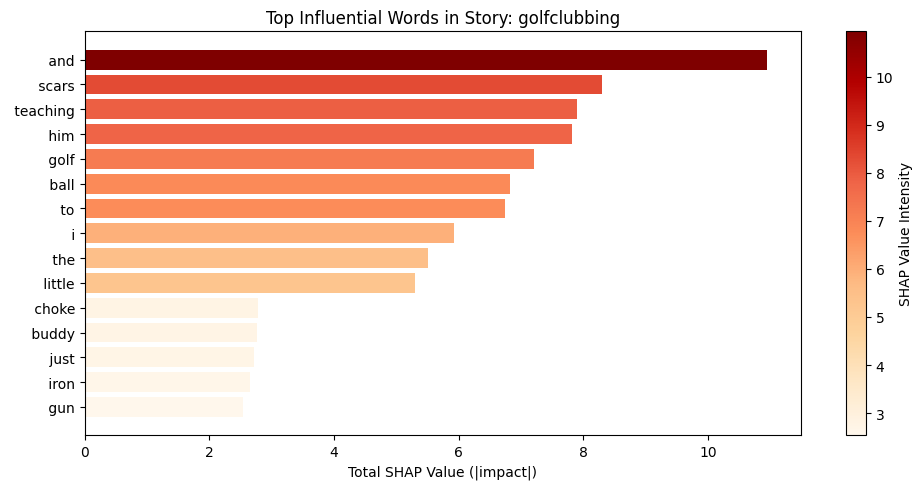

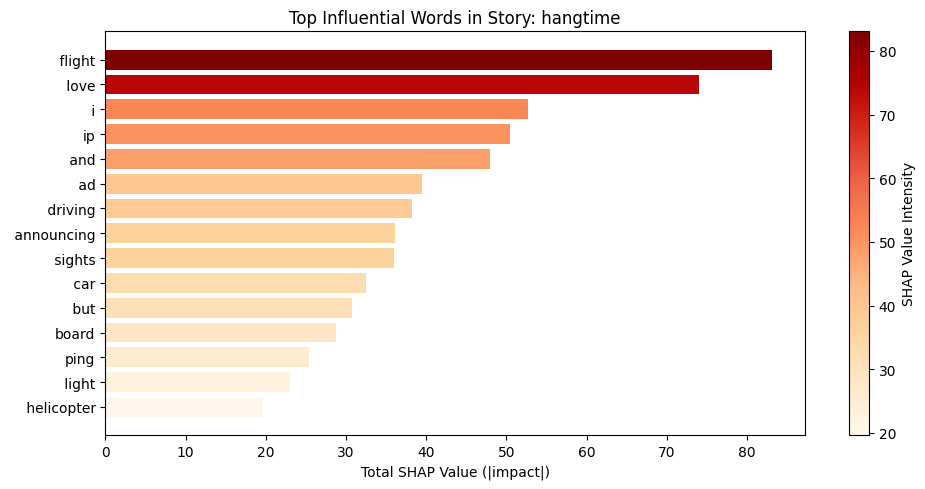

In [65]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict

def plot_colored_barh_per_story(summary, top_k=15, savefig=True):
    story_word_scores = defaultdict(lambda: defaultdict(float))

    for entry in summary:
        story = entry["story"]
        for word, score in entry["top_words"]:
            story_word_scores[story][word] += abs(score)

    for story, word_dict in story_word_scores.items():
        # top_k
        top_words = sorted(word_dict.items(), key=lambda x: x[1], reverse=True)[:top_k]
        words, scores = zip(*top_words)

        # Normalize for color mapping
        norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
        colors = cm.OrRd(norm(scores))  

        plt.figure(figsize=(10, 5))
        bars = plt.barh(words[::-1], scores[::-1], color=colors[::-1])
        plt.xlabel("Total SHAP Value (|impact|)")
        plt.title(f"Top Influential Words in Story: {story}")
        sm = cm.ScalarMappable(cmap=cm.OrRd, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=plt.gca())
        cbar.set_label("SHAP Value Intensity")
        plt.tight_layout()
        plt.show()

plot_colored_barh_per_story(summary, top_k=15)


LIME

In [69]:
from lime.lime_text import LimeTextExplainer
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

def explain_voxel_by_lime(story_id, voxel_index, model, tokenizer, raw_text, max_sentences=10, display=True):

    def predict(texts):
        tokens = tokenizer(texts, padding=True, truncation=True,
                           return_tensors="pt", max_length=16).to(model.bert.device)
        with torch.no_grad():
            outputs = model(tokens["input_ids"], tokens["attention_mask"])
        return outputs[:, voxel_index].detach().cpu().numpy().reshape(-1, 1)
    
    def make_sentences(raw_seq, window_size=8):
        words = raw_seq.data
        return [" ".join(words[i - window_size:i + window_size])
                for i in range(window_size, len(words) - window_size)]

    if story_id not in raw_text:
        raise ValueError(f"Story '{story_id}' not found in raw_text.")

    sentences = make_sentences(raw_text[story_id])[:max_sentences]


    class_names = ["voxel_activation"]
    explainer = LimeTextExplainer(class_names=class_names)

    word_scores = defaultdict(float)
    word_counts = defaultdict(int)


    for i, sentence in enumerate(sentences):
        exp = explainer.explain_instance(sentence, predict, num_features=10, labels=[0])
        for word, val in exp.as_list(label=0):
            word_scores[word] += val
            word_counts[word] += 1

    averaged_scores = {w: word_scores[w] / word_counts[w] for w in word_scores}
    top_words = sorted(averaged_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:10]

    print(f"\n Top influential words for voxel {voxel_index} in story '{story_id}' (LIME):")
    for word, score in top_words:
        print(f"{word:<10}  {score:.4f}")

    return top_words


In [70]:
def batch_explain_voxels_lime(top_voxel_results, model, tokenizer, raw_text, max_sentences=10):
    all_results = []
    for i, item in enumerate(top_voxel_results):
        story = item["story"]
        voxel_id = item["voxel_id"]
        print(f"\n [{i+1}/{len(top_voxel_results)}] LIME explaining voxel {voxel_id} in story '{story}'")
        try:
            top_words = explain_voxel_by_lime(story, voxel_id, model, tokenizer, raw_text, max_sentences=max_sentences)
            all_results.append({
                "story": story,
                "voxel_id": voxel_id,
                "top_words": top_words
            })
        except Exception as e:
            print(f" Failed on voxel {voxel_id}, story '{story}': {e}")
    return all_results

lime_summary = batch_explain_voxels_lime(top_voxel_results, model, tokenizer, raw_text)


 [1/10] LIME explaining voxel 69895 in story 'golfclubbing'

 Top influential words for voxel 69895 in story 'golfclubbing' (LIME):
scars       -0.4793
teaching    -0.4042
remember    -0.2196
actually    0.1950
my          -0.1350
got         0.1076
first       -0.0941
scar        0.0880
the         -0.0616
old         -0.0574

 [2/10] LIME explaining voxel 74985 in story 'golfclubbing'

 Top influential words for voxel 74985 in story 'golfclubbing' (LIME):
scars       -0.1661
teaching    -0.1042
remember    -0.0941
the         -0.0715
was         -0.0540
actually    0.0428
six         0.0371
old         -0.0367
two         -0.0335
first       -0.0272

 [3/10] LIME explaining voxel 75057 in story 'golfclubbing'

 Top influential words for voxel 75057 in story 'golfclubbing' (LIME):
scars       -0.0418
first       0.0295
years       0.0207
six         0.0194
little      0.0184
i           -0.0171
ever        0.0154
two         -0.0139
the         -0.0126
teaching    0.0120

 [4/10] LIM

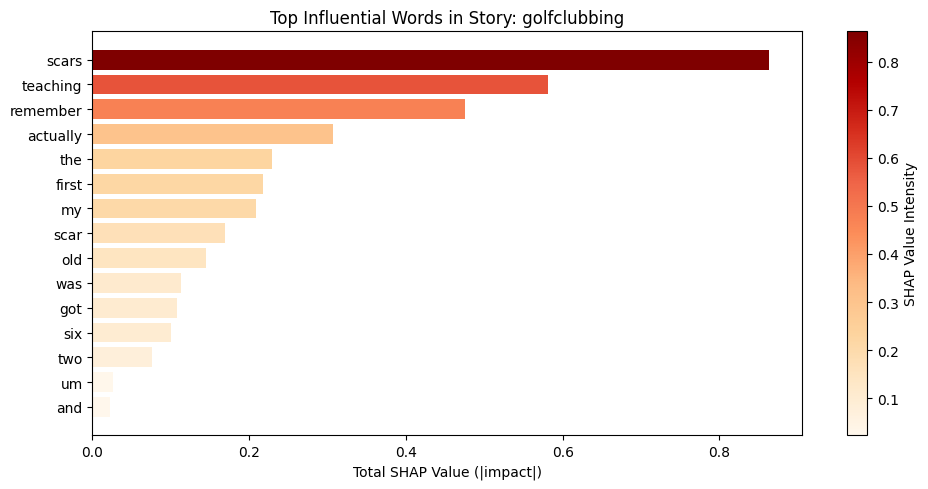

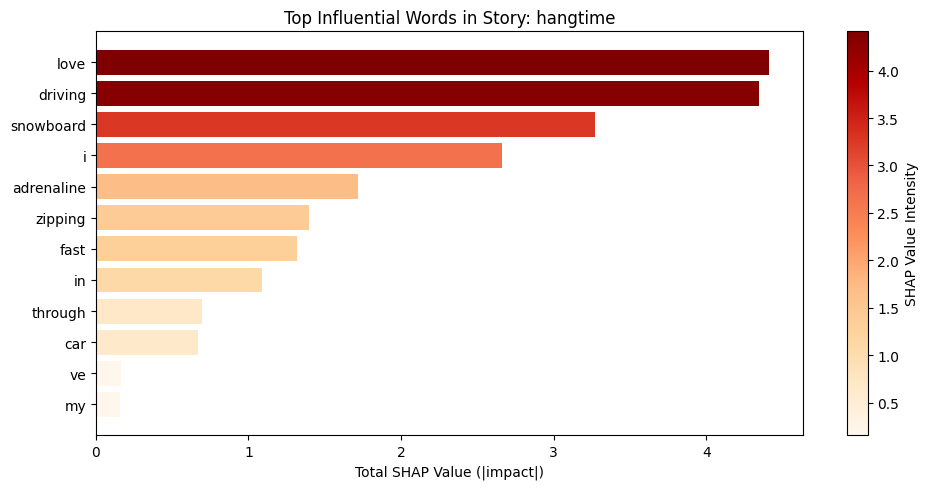

In [72]:
plot_colored_barh_per_story(lime_summary, top_k=15)